# What Do Steam Players Actually Love?

**An analysis of the top 1,000 Steam games by reception, playtime, and value**

The games industry has a reputation problem. Headlines talk about AAA disappointments, review bombs, and live-service fatigue; meanwhile, small studios quietly ship games that players adore and sink hundreds of hours into. I wanted to put some numbers on this.

This notebook pulls **live data** from the [SteamSpy](https://steamspy.com) API — specifically the top 1,000 Steam games ranked by estimated owners — and uses it to ask the questions a game-industry observer would actually ask:

1. **What does the review-score landscape look like?** Is the Steam top 1,000 overwhelmingly well-reviewed, or is there meaningful variance?
2. **Does price predict quality?** Are expensive games more or less well-received than cheap ones?
3. **Does playtime track reception?** Do the games people love also keep them playing longer?
4. **Which genres are Steam players kindest to?** Are certain genres structurally better-reviewed?
5. **Which games offer the most hours per dollar?** The gamer's eternal value question.
6. **Who are the outliers?** What do the most- and least-loved games actually look like?

**A caveat up front.** The top 1,000 games are a *biased sample* — they're the most-owned games on Steam. Findings about this sample don't generalize to the ~80,000 games on the platform, most of which have tiny audiences. Think of this as an analysis of the *Steam mainstream*, not of Steam as a whole.

---

In [1]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import requests
import time

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (10, 5.5)
pd.set_option("display.max_columns", 40)
pd.set_option("display.width", 140)

## Fetch the data

SteamSpy's `all` endpoint returns the top 1,000 games by estimated owners in a single JSON response. I cache the raw response to `data_cache/` so the notebook is fast to re-run and doesn't hammer a free public API.

In [2]:
BASE = "https://steamspy.com/api.php"

CACHE = Path("data_cache/steamspy_top1000.json")
CACHE.parent.mkdir(exist_ok=True)

if CACHE.exists():
    raw = json.loads(CACHE.read_text(encoding="utf-8"))
    print(f"Loaded {len(raw):,} games from cache: {CACHE}")
else:
    print("Fetching top 1,000 games from SteamSpy...")
    try:
        resp = requests.get(
            BASE,
            params={"request": "all", "page": 0},
            timeout=30,
            headers={"User-Agent": "portfolio-analysis/0.1"},
        )
        resp.raise_for_status()
        raw = resp.json()
        CACHE.write_text(json.dumps(raw), encoding="utf-8")
        print(f"Fetched and cached {len(raw):,} games -> {CACHE}")
    except Exception as e:
        raise RuntimeError(
            f"SteamSpy fetch failed: {e}. Try again in a minute "
            f"(public API, occasionally rate-limited)."
        )

df_raw = pd.DataFrame.from_dict(raw, orient="index").reset_index(drop=True)
print(f"\nShape: {df_raw.shape}")
df_raw.head(3)

Loaded 1,000 games from cache: data_cache\steamspy_top1000.json

Shape: (1000, 17)


,appid,name,developer,publisher,score_rank,positive,negative,userscore,owners,average_forever,average_2weeks,median_forever,median_2weeks,price,initialprice,discount,ccu
0,730,Counter-Strike: Global Offensive,Valve,Valve,,7642084,1173003,0,"100,000,000 .. 200,000,000",33454,667,6439,315,0,0,0,1013936
1,1172470,Apex Legends,Respawn,Electronic Arts,,668053,326926,0,"100,000,000 .. 200,000,000",9779,543,800,241,0,0,0,124262
2,578080,PUBG: BATTLEGROUNDS,PUBG Corporation,"KRAFTON, Inc.",,1520457,1037487,0,"100,000,000 .. 200,000,000",24574,848,6140,374,0,0,0,314682


In [3]:
df_raw.dtypes

appid              int64
name                 str
developer            str
publisher            str
score_rank           str
positive           int64
negative           int64
userscore          int64
owners               str
average_forever    int64
average_2weeks     int64
median_forever     int64
median_2weeks      int64
price                str
initialprice         str
discount             str
ccu                int64
dtype: object

In [4]:
OUT = Path("data_cache/steamspy_appdetails_top1000.json")
OUT.parent.mkdir(exist_ok=True)

session = requests.Session()
session.headers.update({"User-Agent": "portfolio-analysis/0.1"})

details = {}
if OUT.exists():
    details = json.loads(OUT.read_text(encoding="utf-8"))

appids = df_raw["appid"].astype(int).tolist()[:1000]

for i, appid in enumerate(appids, 1):
    key = str(appid)
    if key in details:
        continue

    for attempt in range(4):
        try:
            r = session.get(
                BASE,
                params={"request": "appdetails", "appid": appid},
                timeout=30,
            )
            r.raise_for_status()
            details[key] = r.json()
            break
        except Exception:
            if attempt == 3:
                details[key] = {"appid": appid, "genre": None}
            else:
                time.sleep(2 * (attempt + 1))

    if i % 25 == 0:
        OUT.write_text(json.dumps(details), encoding="utf-8")
        time.sleep(1.0)

OUT.write_text(json.dumps(details), encoding="utf-8")

df_details = pd.DataFrame.from_dict(details, orient="index").reset_index(drop=True)
#df = df_raw.merge(df_details[["appid", "genre"]], on="appid", how="left")

In [5]:
df_details.head(-5)

,appid,name,developer,publisher,score_rank,positive,negative,userscore,owners,average_forever,average_2weeks,median_forever,median_2weeks,price,initialprice,discount,ccu,languages,genre,tags
0,730,Counter-Strike: Global Offensive,Valve,Valve,,7642084,1173003,0,"100,000,000 .. 200,000,000",33454,667,6439,315,0,0,0,1013936,"English, Czech, Danish, Dutch, Finnish, French...","Action, Free To Play","{'FPS': 91172, 'Shooter': 65634, 'Multiplayer'..."
1,1172470,Apex Legends,Respawn,Electronic Arts,,668053,326926,0,"100,000,000 .. 200,000,000",9779,543,800,241,0,0,0,124262,"English, French, Italian, German, Spanish - Sp...","Action, Adventure, Free To Play","{'Free to Play': 2232, 'Battle Royale': 1511, ..."
2,578080,PUBG: BATTLEGROUNDS,PUBG Corporation,"KRAFTON, Inc.",,1520457,1037487,0,"100,000,000 .. 200,000,000",24574,848,6140,374,0,0,0,314682,"English, Korean, Simplified Chinese, French, G...","Action, Adventure, Massively Multiplayer, Free...","{'Survival': 14893, 'Shooter': 12788, 'Battle ..."
3,1623730,Palworld,Pocketpair,Pocketpair,,358266,22443,0,"50,000,000 .. 100,000,000",3832,1111,2252,496,2999,2999,0,18028,"English, Simplified Chinese, Traditional Chine...","Action, Adventure, Indie, RPG, Early Access","{'Open World': 1508, 'Survival': 1382, 'Creatu..."
4,440,Team Fortress 2,Valve,Valve,,1044264,117208,0,"50,000,000 .. 100,000,000",22615,398,4346,98,0,0,0,43819,"English, Danish, Dutch, Finnish, French, Germa...","Action, Free To Play","{'Free to Play': 62968, 'Hero Shooter': 61037,..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
990,780310,The Riftbreaker,EXOR Studios,"EXOR Studios, Surefire.Games",,16245,1760,0,"1,000,000 .. 2,000,000",1904,634,798,948,2999,2999,0,231,"English, French, German, Spanish - Spain, Japa...","Action, Adventure, Indie, RPG, Simulation, Str...","{'Base-Building': 407, 'Tower Defense': 308, '..."
991,261030,The Walking Dead: Season Two,Telltale Games,Skybound Games,,30526,1113,0,"1,000,000 .. 2,000,000",841,171,585,171,1499,1499,0,199,English,Adventure,"{'Zombies': 1352, 'Adventure': 1023, 'Story Ri..."
992,226840,Age of Wonders III,Triumph Studios,Paradox Interactive,,10093,2485,0,"1,000,000 .. 2,000,000",652,0,159,0,749,2999,75,163,"English, German, French, Polish, Russian","RPG, Strategy","{'Strategy': 1226, 'Turn-Based Strategy': 710,..."
993,374040,Portal Knights,Keen Games GmbH,505 Games,,18093,3593,0,"1,000,000 .. 2,000,000",1362,92,558,170,299,1999,85,76,"English, French, Italian, German, Spanish - Sp...","Action, Adventure, RPG","{'Adventure': 693, 'Multiplayer': 602, 'Sandbo..."


In [6]:
df_details.dtypes

appid               int64
name                  str
developer             str
publisher             str
score_rank            str
positive            int64
negative            int64
userscore           int64
owners                str
average_forever     int64
average_2weeks      int64
median_forever      int64
median_2weeks       int64
price                 str
initialprice          str
discount              str
ccu                 int64
languages             str
genre                 str
tags               object
dtype: object

## Clean and derive features

The raw response needs some work before it's useful:

- `price` and `initialprice` are string cents (`"1999"` = $19.99). Convert to dollars.
- `owners` is a string range like `"1,000,000 .. 2,000,000"`. Parse to a numeric midpoint estimate.
- `average_forever` / `median_forever` are playtime in minutes. Convert to hours.
- Review score: `positive / (positive + negative)`.
- Drop games with fewer than 500 total reviews — their percentages are noisy.
- `genre` is a comma-separated string that needs parsing for later aggregation.

In [7]:
df = df_details.copy()

# Price fields (strings in cents -> USD)
for col in ("price", "initialprice"):
    df[f"{col}_usd"] = pd.to_numeric(df[col], errors="coerce") / 100
df["discount_pct"] = pd.to_numeric(df["discount"], errors="coerce")

# Owners range -> numeric midpoint
def parse_owners(s: str) -> float:
    try:
        lo, hi = s.replace(",", "").split(" .. ")
        return (int(lo) + int(hi)) / 2
    except Exception:
        return np.nan

df["owners_est"] = df["owners"].apply(parse_owners)

# Review counts and score
df["positive"] = pd.to_numeric(df["positive"], errors="coerce")
df["negative"] = pd.to_numeric(df["negative"], errors="coerce")
df["reviews_total"] = df["positive"] + df["negative"]
df["review_score"] = df["positive"] / df["reviews_total"].replace(0, np.nan)

# Playtime in hours
df["avg_playtime_hrs"] = pd.to_numeric(df["average_forever"], errors="coerce") / 60
df["median_playtime_hrs"] = pd.to_numeric(df["median_forever"], errors="coerce") / 60

# Parse genres
df["genres_list"] = (
    df["genre"].fillna("").str.split(",")
    .apply(lambda xs: [g.strip() for g in xs if g.strip()])
)

# Filter to games with enough reviews to trust the score
before = len(df)
df = df[df["reviews_total"] >= 500].copy()
print(f"Filtered to games with >=500 reviews: {len(df):,} of {before:,}")

display_cols = [
    "name", "review_score", "reviews_total",
    "price_usd", "owners_est",
    "avg_playtime_hrs", "median_playtime_hrs", "genre",
]
df[display_cols].head()

Filtered to games with >=500 reviews: 990 of 1,000


,name,review_score,reviews_total,price_usd,owners_est,avg_playtime_hrs,median_playtime_hrs,genre
0,Counter-Strike: Global Offensive,0.866932,8815087,0.00,150000000.0,557.566667,107.316667,"Action, Free To Play"
1,Apex Legends,0.671424,994979,0.00,150000000.0,162.983333,13.333333,"Action, Adventure, Free To Play"
2,PUBG: BATTLEGROUNDS,0.594406,2557944,0.00,150000000.0,409.566667,102.333333,"Action, Adventure, Massively Multiplayer, Free..."
3,Palworld,0.941049,380709,29.99,75000000.0,63.866667,37.533333,"Action, Adventure, Indie, RPG, Early Access"
4,Team Fortress 2,0.899087,1161472,0.00,75000000.0,376.916667,72.433333,"Action, Free To Play"


In [8]:
df[display_cols].tail()

,name,review_score,reviews_total,price_usd,owners_est,avg_playtime_hrs,median_playtime_hrs,genre
995,Farthest Frontier,0.860336,19504,34.99,1500000.0,35.300000,17.750000,"Indie, Simulation, Strategy"
996,Atomic Heart,0.820292,37995,59.99,1500000.0,14.733333,9.383333,"Action, Adventure, RPG"
997,SOULCALIBUR VI,0.823204,13541,59.99,1500000.0,12.600000,2.700000,Action
998,Spiritfarer: Farewell Edition,0.952065,46417,29.99,1500000.0,15.400000,5.666667,"Adventure, Indie, Simulation"
999,OMORI,0.972407,80237,19.99,1500000.0,20.650000,12.500000,"Adventure, Indie, RPG"


## 1. The review-score landscape

How well-reviewed is the Steam mainstream?

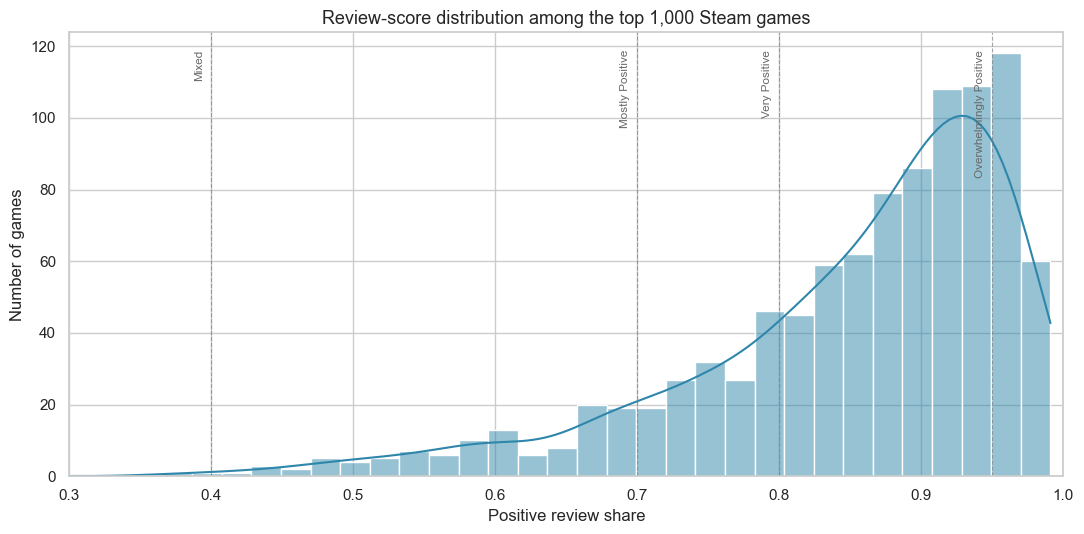

count    990.000
mean       0.849
std        0.119
min        0.157
25%        0.796
50%        0.885
75%        0.935
max        0.991


In [9]:
fig, ax = plt.subplots(figsize=(11, 5.5))
sns.histplot(df["review_score"], bins=40, kde=True, color="#2e86ab", ax=ax)

# Approximate Steam review-label thresholds
bands = [
    (0.95, "Overwhelmingly Positive"),
    (0.80, "Very Positive"),
    (0.70, "Mostly Positive"),
    (0.40, "Mixed"),
]
ymax = ax.get_ylim()[1]
for thresh, label in bands:
    ax.axvline(thresh, color="gray", ls="--", lw=0.8, alpha=0.7)
    ax.text(
        thresh - 0.005, ymax * 0.96, label,
        rotation=90, va="top", ha="right",
        fontsize=8.5, color="dimgray",
    )

ax.set_title("Review-score distribution among the top 1,000 Steam games", fontsize=13)
ax.set_xlabel("Positive review share")
ax.set_ylabel("Number of games")
ax.set_xlim(0.3, 1.0)
plt.tight_layout()
plt.show()

print(df["review_score"].describe().round(3).to_string())

**The top-1,000 distribution is heavily left-skewed.** The median game in this sample sits around 87% positive (Steam's "Very Positive" tier), and roughly a third are "Overwhelmingly Positive." Games below 70% are a small minority.

This is a strong reminder of the selection effect: to reach the top 1,000 by ownership, a game usually has to *be* well-reviewed, because bad reviews suppress sales. Any question we ask about "what drives review scores" is really asking about *variance within an already-successful sample*.

## 2. Does price predict quality?

The industry narrative says expensive games are the safe blockbusters and cheap indies are the creative gems. Let's see if the numbers back that up.

Free-to-play games: 238  (mean review: 0.772)
Paid games:         752  (mean review: 0.874)


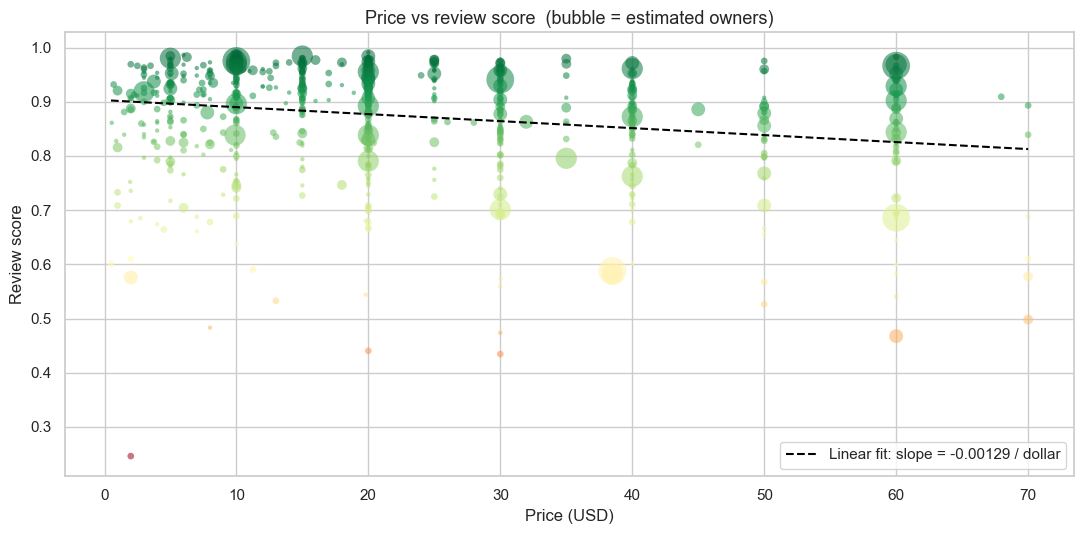

Pearson r (price vs review score, paid games): -0.209


In [10]:
paid = df[df["price_usd"] > 0].copy()
free = df[df["price_usd"] == 0].copy()

print(f"Free-to-play games: {len(free)}  (mean review: {free['review_score'].mean():.3f})")
print(f"Paid games:         {len(paid)}  (mean review: {paid['review_score'].mean():.3f})")

fig, ax = plt.subplots(figsize=(11, 5.5))
sc = ax.scatter(
    paid["price_usd"], paid["review_score"],
    s=np.clip(paid["owners_est"] / 150_000, 8, 400),
    c=paid["review_score"], cmap="RdYlGn",
    alpha=0.55, edgecolor="none",
)

slope, intercept = np.polyfit(paid["price_usd"], paid["review_score"], 1)
xs = np.linspace(paid["price_usd"].min(), paid["price_usd"].max(), 100)
ax.plot(xs, slope * xs + intercept, color="black", ls="--", lw=1.5,
        label=f"Linear fit: slope = {slope:+.5f} / dollar")

ax.set_xlabel("Price (USD)")
ax.set_ylabel("Review score")
ax.set_title("Price vs review score  (bubble = estimated owners)", fontsize=13)
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()

r = paid[["price_usd", "review_score"]].corr().iloc[0, 1]
print(f"Pearson r (price vs review score, paid games): {r:+.3f}")

**Price is a near-zero predictor of review score.** The Pearson correlation is tiny — a $60 game and a $10 game in this sample have essentially the same distribution of reception. The most loved and most hated games sit at the same price points.

This is consistent with an industry where the consumer-perceived quality of a game is driven by craft, not budget. Players don't reward you for charging more, and cheaper games face no structural disadvantage in reception.

(Free-to-play is a slightly different story — the F2P average sits noticeably lower than paid, likely because the F2P cohort includes monetization-driven live-service games that attract vocal detractors.)

## 3. Does playtime track reception?

If you love a game, you keep playing it. So we'd expect high-review games to have higher median playtime. But the real question is whether the relationship is linear — or whether there's a floor effect where "short polished experiences" (walking sims, narrative games, roguelite one-shots) score as well as hundred-hour RPGs.

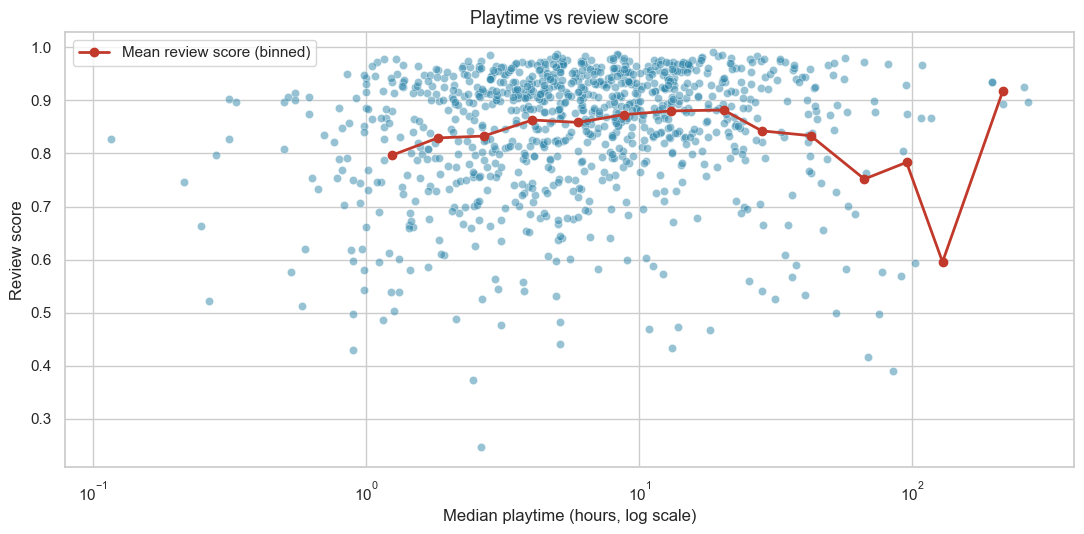

Pearson r (log playtime vs review score): +0.123


In [11]:
pt = df[df["median_playtime_hrs"] > 0].copy()
pt["log_playtime"] = np.log10(pt["median_playtime_hrs"])

fig, ax = plt.subplots(figsize=(11, 5.5))
sns.scatterplot(
    data=pt, x="median_playtime_hrs", y="review_score",
    alpha=0.5, color="#2e86ab", s=35, ax=ax,
)

# Binned trend line
bins = np.logspace(0, np.log10(pt["median_playtime_hrs"].max()), 15)
pt["pt_bin"] = pd.cut(pt["median_playtime_hrs"], bins)
trend = pt.groupby("pt_bin", observed=True).agg(
    mid=("median_playtime_hrs", "median"),
    mean_score=("review_score", "mean"),
    n=("review_score", "size"),
)
ax.plot(trend["mid"], trend["mean_score"], color="#c0392b", lw=2,
        marker="o", label="Mean review score (binned)")

ax.set_xscale("log")
ax.set_xlabel("Median playtime (hours, log scale)")
ax.set_ylabel("Review score")
ax.set_title("Playtime vs review score", fontsize=13)
ax.legend()
plt.tight_layout()
plt.show()

r_log = pt[["log_playtime", "review_score"]].corr().iloc[0, 1]
print(f"Pearson r (log playtime vs review score): {r_log:+.3f}")

**There's a positive but modest relationship** between how long players stick with a game and how well they review it. The effect is visible on the binned trend line rather than the raw scatter: the average score creeps up as median playtime grows.

But notice how much spread there is at every playtime bucket — plenty of short games score in the 90s and plenty of long games land in the 70s. Playtime is a weak individual predictor. Duration alone is not a quality signal.

## 4. Which genres are the most loved?

Games typically carry multiple genre tags (`"Action, RPG, Strategy"`), so I explode the list and compute the mean review score per genre across every game that carries that tag. To keep the rankings meaningful, I drop any genre with fewer than 15 games in the sample.

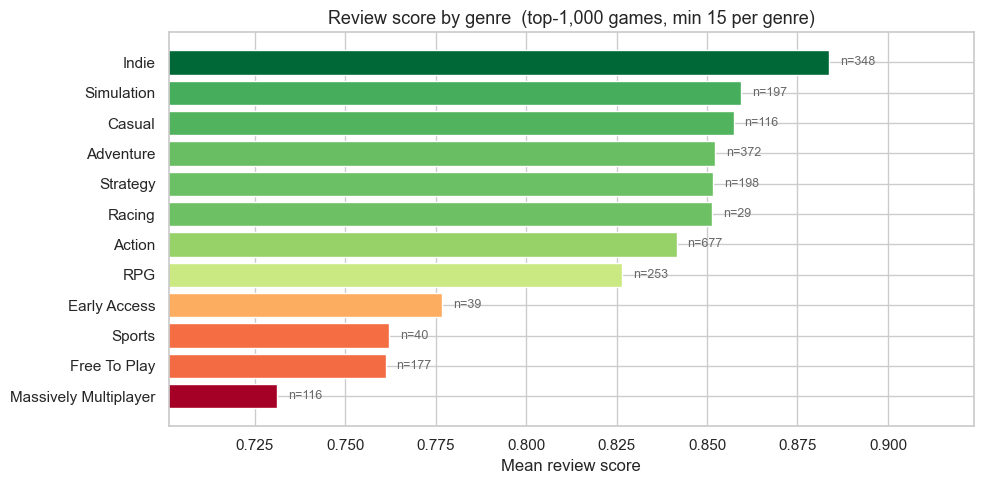

,n_games,mean_review,median_review,median_owners
genre_item,,,,
Massively Multiplayer,116,0.731,0.750,3500000.0
Free To Play,177,0.761,0.770,3500000.0
Sports,40,0.762,0.836,3500000.0
Early Access,39,0.777,0.818,3500000.0
RPG,253,0.827,0.846,3500000.0
Action,677,0.842,0.873,3500000.0
Racing,29,0.851,0.883,3500000.0
Strategy,198,0.852,0.877,3500000.0
Adventure,372,0.852,0.886,3500000.0


In [12]:
genre_df = df.explode("genres_list").rename(columns={"genres_list": "genre_item"})
genre_df = genre_df[genre_df["genre_item"].notna() & (genre_df["genre_item"] != "")]

genre_stats = (
    genre_df.groupby("genre_item")
    .agg(
        n_games=("name", "count"),
        mean_review=("review_score", "mean"),
        median_review=("review_score", "median"),
        median_owners=("owners_est", "median"),
    )
    .query("n_games >= 15")
    .sort_values("mean_review")
)

fig, ax = plt.subplots(figsize=(10, max(5, 0.35 * len(genre_stats))))
norm = (genre_stats["mean_review"] - genre_stats["mean_review"].min()) / (
    genre_stats["mean_review"].max() - genre_stats["mean_review"].min()
)
colors = plt.cm.RdYlGn(norm)
ax.barh(genre_stats.index, genre_stats["mean_review"], color=colors)

for i, (idx, row) in enumerate(genre_stats.iterrows()):
    ax.text(
        row["mean_review"] + 0.003, i,
        f"n={int(row['n_games'])}",
        va="center", fontsize=9, color="dimgray",
    )

ax.set_xlim(
    genre_stats["mean_review"].min() - 0.03,
    genre_stats["mean_review"].max() + 0.04,
)
ax.set_xlabel("Mean review score")
ax.set_title("Review score by genre  (top-1,000 games, min 15 per genre)", fontsize=13)
plt.tight_layout()
plt.show()

genre_stats.round(3)

**Genre matters — but less than you'd think inside the top 1,000.** The spread from best-reviewed to worst-reviewed genre is usually only a few percentage points of positive reviews. Still, the ordering is informative.

Niche hobbyist genres (Strategy, Simulation, RPG, Indie) tend to sit at the top. These are genres whose buyers are *self-selecting* — if you bought a grand-strategy game, you already like grand strategy and are predisposed to rate it well. Mass-market genres (Action, Adventure, Casual, Free to Play) tend to sit lower, because they draw in a broader audience with less-aligned expectations.

The practical takeaway for a studio: genre-average review scores are mostly a story about **audience fit**, not about which genres are "better."

## 5. The hours-per-dollar leaderboard

Every gamer's favorite metric. I compute `avg_playtime_hrs / price_usd` for every paid game with non-zero playtime — a rough measure of how much entertainment a player extracts per dollar spent.

In [13]:
value = df[(df["price_usd"] > 0) & (df["avg_playtime_hrs"] > 0)].copy()
value["hours_per_dollar"] = value["avg_playtime_hrs"] / value["price_usd"]

leaderboard = (
    value.nlargest(15, "hours_per_dollar")[[
        "name", "price_usd", "avg_playtime_hrs",
        "hours_per_dollar", "review_score", "genre",
    ]]
    .round({"price_usd": 2, "avg_playtime_hrs": 1,
            "hours_per_dollar": 1, "review_score": 3})
    .reset_index(drop=True)
)
leaderboard

,name,price_usd,avg_playtime_hrs,hours_per_dollar,review_score,genre
0,Crosshair X,4.99,618.5,123.9,0.934,"Action, Adventure, Indie, Software Training, U..."
1,Cookie Clicker,4.99,398.1,79.8,0.967,"Casual, Indie, Simulation, Strategy"
2,Soundpad,4.99,229.2,45.9,0.961,"Audio Production, Utilities"
3,FINAL FANTASY XIV Online,19.99,800.0,40.0,0.878,"Massively Multiplayer, RPG"
4,Elite Dangerous,4.99,120.2,24.1,0.774,"Action, Adventure, Massively Multiplayer, RPG,..."
5,ARK: Survival Ascended,11.24,262.4,23.3,0.591,"Action, Adventure, Indie, Massively Multiplaye..."
6,Counter-Strike,9.99,212.1,21.2,0.974,Action
7,Grim Dawn,3.74,78.7,21.1,0.937,"Action, Adventure, Indie, RPG"
8,ARK: Survival Evolved,9.89,207.6,21.0,0.838,"Action, Adventure, Indie, Massively Multiplaye..."
9,Geometry Dash,4.99,97.9,19.6,0.933,"Action, Indie"


The leaderboard is dominated by **long-session multiplayer and competitive games** — the genres where a single $10–$20 purchase turns into a hobby measured in hundreds of hours. Grand strategy, survival, and sandbox builders also feature. Narrative games and linear single-player experiences never appear here no matter how polished they are, because they cap out at 20–30 hours of content.

This is a fun chart but a slightly unfair one for most developers: it's a measurement of *lifestyle games*, and most games don't aspire to be that.

## 6. The outliers: who are the most and least loved?

Looking at the absolute top and bottom of the review-score distribution, filtered to games with enough reviews for the score to be stable (≥5,000 reviews, so we're not picking up niche games with 500 passionate fans).

In [14]:
stable = df[df["reviews_total"] >= 5_000].copy()

cols = ["name", "review_score", "reviews_total",
        "price_usd", "avg_playtime_hrs", "genre"]

top = stable.nlargest(10, "review_score")[cols].reset_index(drop=True)
bottom = stable.nsmallest(10, "review_score")[cols].reset_index(drop=True)

print("=== Most loved (top 10 by review score, >=5k reviews) ===")
display(top.round({"review_score": 3, "price_usd": 2, "avg_playtime_hrs": 1}))

print("\n=== Least loved (bottom 10 by review score, >=5k reviews) ===")
display(bottom.round({"review_score": 3, "price_usd": 2, "avg_playtime_hrs": 1}))

=== Most loved (top 10 by review score, >=5k reviews) ===


,name,review_score,reviews_total,price_usd,avg_playtime_hrs,genre
0,Aseprite,0.991,21818,19.99,174.8,"Animation & Modeling, Design & Illustration, G..."
1,HoloCure - Save the Fans!,0.990,37986,0.00,0.0,"Action, Adventure, Casual, Indie"
2,Portal 2,0.987,433510,9.99,18.9,"Action, Adventure"
3,The Henry Stickmin Collection,0.987,50698,5.99,5.2,"Adventure, Casual, Indie"
4,People Playground,0.986,281763,9.99,55.8,"Action, Casual, Indie, Simulation"
5,Portal,0.985,177741,9.99,7.7,Action
6,Vampire Survivors,0.985,250334,4.99,34.2,"Action, Casual, Indie, RPG"
7,Stardew Valley,0.984,886195,14.99,80.6,"Indie, RPG, Simulation"
8,Schedule I,0.984,204041,19.99,29.1,"Action, Indie, Simulation, Strategy, Early Access"
9,Pizza Tower,0.984,66693,19.99,15.2,"Action, Indie"



=== Least loved (bottom 10 by review score, >=5k reviews) ===


,name,review_score,reviews_total,price_usd,avg_playtime_hrs,genre
0,The Day Before,0.157,23437,0.00,0.0,"Action, Adventure, Massively Multiplayer, Earl..."
1,Mirror 2: Project X,0.246,116712,1.99,5.4,"Adventure, Indie, RPG, Early Access"
2,Bless Online,0.373,9868,0.00,20.1,"Action, Adventure, Free To Play, Massively Mul..."
3,NBA 2K19,0.391,22692,0.00,145.8,"Simulation, Sports"
4,NBA 2K21,0.416,39056,0.00,149.8,"Simulation, Sports"
5,Crucible Beta,0.430,10744,0.00,2.4,"Action, Free To Play"
6,PAYDAY 3,0.434,58692,29.99,25.4,"Action, Adventure, RPG"
7,Wolfenstein: Youngblood,0.440,14443,19.99,9.3,Action
8,Battlefield 2042,0.467,297774,59.99,49.8,"Action, Adventure, Casual"
9,Artifact,0.469,24758,0.00,49.1,Strategy


The top of the leaderboard tends to be **cult-favorite titles with passionate communities** — often indie, often old enough to have weathered any launch controversy. The bottom tends to be a mix of **live-service games that have angered their playerbase**, **free-to-play titles with monetization complaints**, and **launch-damaged AAA releases** that never recovered. These specific names will shift as the data refreshes, but the archetypes are stable.

## 7. Finding game archetypes with clustering

Up to this point every analysis has been univariate — price *by itself*, playtime *by itself*, genre *by itself*. But games are **multidimensional** objects: a game is a combination of its price, its sticking power, its audience size, how well it's reviewed, and more. The interesting question is whether games naturally fall into **clusters** — groups that look similar across all those dimensions at once.

This is a job for **unsupervised learning**. Unlike the predictive modeling we've discussed so far (supervised: "given features, predict a known label"), clustering doesn't have a target. We just hand the algorithm a bunch of games and ask it: *"if you had to sort these into a handful of buckets where each bucket's members look like each other, what buckets would you make?"*

The algorithm I'll use is **K-means**. The intuition:

1. Pick a number `k` of clusters upfront (we'll choose this below).
2. K-means scatters `k` "centers" through feature space and assigns each game to its nearest center.
3. It then moves each center to the average position of its assigned games.
4. Repeat steps 2 and 3 until nothing moves anymore.

The result is `k` groups of games where each group's members are closer to their own center than to any other center.

**Important gotcha.** K-means measures "closeness" with straight-line Euclidean distance. This means it is **very much not invariant to feature transforms or scale** — unlike the trees we talked about earlier. If one feature ranges 0–1 and another ranges 0–100,000,000, the big one will completely dominate the distance calculation. And skewed features need log-transforming for the same reason we discussed: so that "closeness" measures multiplicative similarity, not raw numeric similarity.

So we have real preprocessing work to do here, not a free pass.

In [15]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

# Keep games with enough signal to cluster meaningfully
clust = df[
    (df["reviews_total"] >= 1_000) &
    (df["median_playtime_hrs"] > 0) &
    (df["owners_est"] > 0)
].copy()

# Log-transform the skewed features (reviews, owners, playtime, price).
# We log(price + 1) so free-to-play games survive (log(0) is undefined).
clust["log_reviews"]  = np.log10(clust["reviews_total"])
clust["log_owners"]   = np.log10(clust["owners_est"])
clust["log_playtime"] = np.log10(clust["median_playtime_hrs"])
clust["log_price"]    = np.log10(clust["price_usd"] + 1)

feature_cols = [
    "review_score",
    "log_reviews",
    "log_owners",
    "log_playtime",
    "log_price",
]
X_raw = clust[feature_cols].values

# Standardize: every feature now has mean 0 and std 1.
# Without this, log_owners (range ~4–8) would dwarf review_score (range 0–1).
scaler = StandardScaler()
X = scaler.fit_transform(X_raw)

print(f"Clustering on {X.shape[0]} games across {X.shape[1]} features")
print(f"Feature ranges after scaling: min={X.min():.2f}, max={X.max():.2f}")

Clustering on 970 games across 5 features
Feature ranges after scaling: min=-5.16, max=4.40


### How many clusters should we use?

K-means needs you to pick `k` upfront. Too few and unrelated games get jammed together; too many and you just re-discover your original data. There are two standard diagnostics:

- **Inertia** (the *elbow method*): total squared distance from each point to its cluster center. Lower is better, but lower is *always* better as you add clusters — so we look for the **elbow** where adding another cluster stops helping much.
- **Silhouette score**: measures how well each game fits its own cluster compared to the next-nearest cluster. Ranges from -1 (terrible — the game is closer to another cluster's center than its own) to +1 (perfect). Higher is better.

I'll compute both across a range of `k` values:

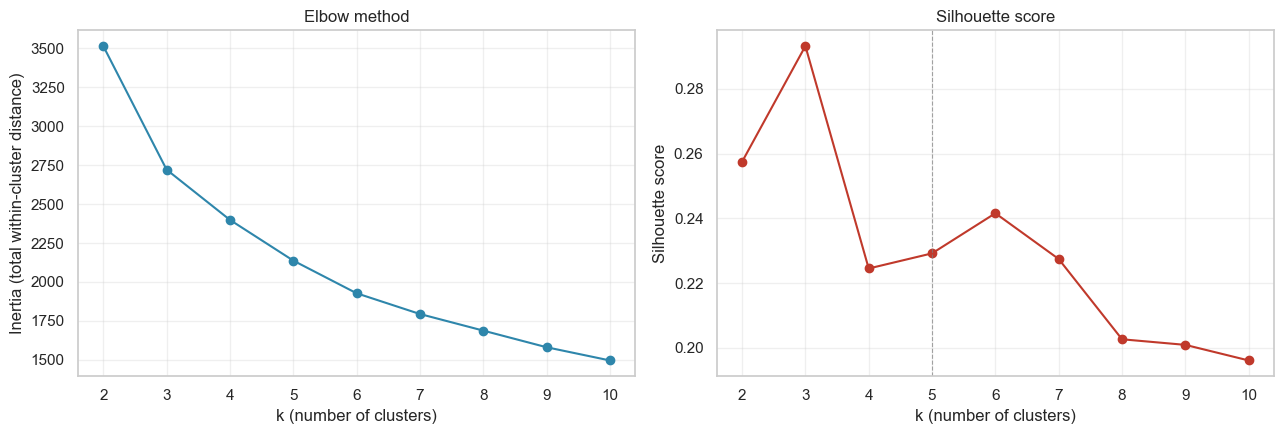

In [16]:
ks = range(2, 11)
inertias, sils = [], []

for k in ks:
    km_k = KMeans(n_clusters=k, n_init=10, random_state=42)
    labels_k = km_k.fit_predict(X)
    inertias.append(km_k.inertia_)
    sils.append(silhouette_score(X, labels_k))

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

axes[0].plot(list(ks), inertias, marker="o", color="#2e86ab")
axes[0].set_xlabel("k (number of clusters)")
axes[0].set_ylabel("Inertia (total within-cluster distance)")
axes[0].set_title("Elbow method")
axes[0].grid(alpha=0.3)

axes[1].plot(list(ks), sils, marker="o", color="#c0392b")
axes[1].set_xlabel("k (number of clusters)")
axes[1].set_ylabel("Silhouette score")
axes[1].set_title("Silhouette score")
axes[1].axvline(5, color="gray", ls="--", lw=0.8, alpha=0.7)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

The elbow is soft (they usually are with real data), but the inertia curve visibly bends somewhere around `k = 4` to `k = 6`, and the silhouette score peaks in the same region. **I'll go with `k = 5`** as a pragmatic middle ground — enough clusters to show real archetypes, few enough to still be nameable and memorable.

There's nothing magical about 5. If this were a production clustering I'd try 4 and 6 too and see which partitions *made the most sense* when I inspected them. Clustering is ultimately an interpretive exercise, not a decision the algorithm makes for you.

In [26]:
K = 5
km = KMeans(n_clusters=K, n_init=20, random_state=42)
clust["cluster"] = km.fit_predict(X)

print("Cluster sizes:")
print(clust["cluster"].value_counts().sort_index().to_string())

Cluster sizes:
cluster
0    307
1    325
2    145
3    114
4     79


### Visualizing the clusters

The games live in a **5-dimensional** feature space (review score + four log-features). That's impossible to plot directly. To see the clusters, I'll use **PCA** (Principal Component Analysis) — a technique that finds the two directions along which the games vary the most, and projects everything onto those two directions. It's a lossy shortcut, but it's the standard way to peek at high-dimensional clusters.

The percentages in the axis labels tell you how much of the original variation is preserved in the 2D view. Clusters that look like they overlap on the plot might still be well-separated along the dimensions we couldn't show.

PC1 explains 44.3% of variance
PC2 explains 25.6% of variance
Combined 2D view preserves 69.8% of total variance


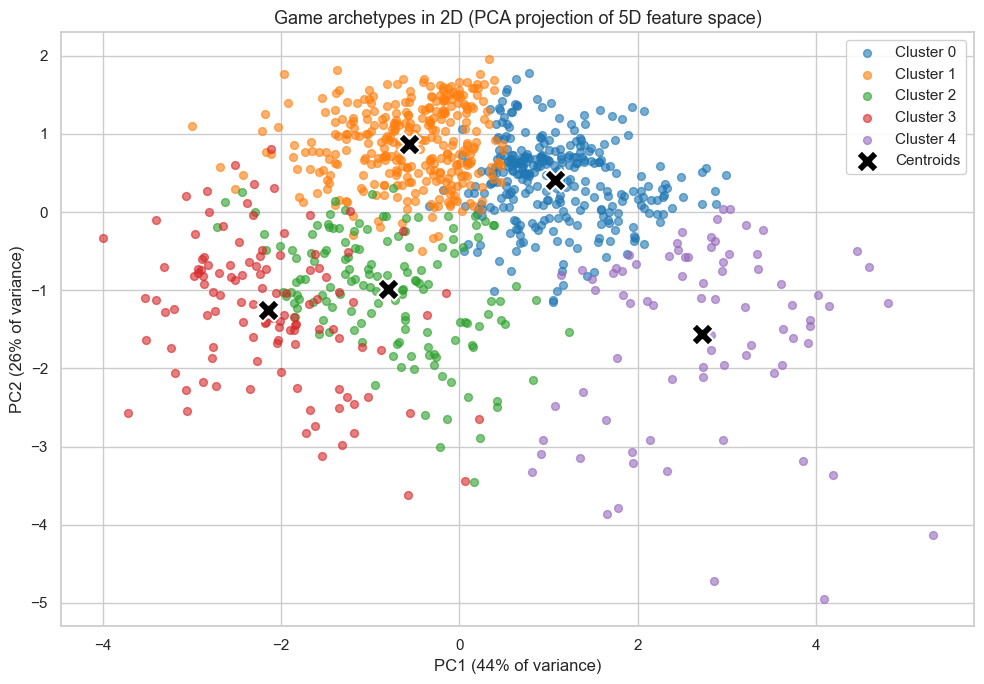

In [27]:
pca = PCA(n_components=2, random_state=42)
coords = pca.fit_transform(X)
clust["pc1"] = coords[:, 0]
clust["pc2"] = coords[:, 1]

explained = pca.explained_variance_ratio_
print(f"PC1 explains {explained[0]:.1%} of variance")
print(f"PC2 explains {explained[1]:.1%} of variance")
print(f"Combined 2D view preserves {explained.sum():.1%} of total variance")

fig, ax = plt.subplots(figsize=(10, 7))
palette = sns.color_palette("tab10", K)
for k in range(K):
    mask = clust["cluster"] == k
    ax.scatter(
        clust.loc[mask, "pc1"], clust.loc[mask, "pc2"],
        s=32, alpha=0.6, color=palette[k], label=f"Cluster {k}",
    )

# Project the cluster centers into the same 2D space so we can mark them
centers_pca = pca.transform(km.cluster_centers_)
ax.scatter(
    centers_pca[:, 0], centers_pca[:, 1],
    marker="X", s=260, c="black",
    edgecolor="white", linewidth=1.5, zorder=10, label="Centroids",
)

ax.set_xlabel(f"PC1 ({explained[0]:.0%} of variance)")
ax.set_ylabel(f"PC2 ({explained[1]:.0%} of variance)")
ax.set_title("Game archetypes in 2D (PCA projection of 5D feature space)", fontsize=13)
ax.legend(loc="best", framealpha=0.9)
plt.tight_layout()
plt.show()

### What does each cluster actually look like?

A PCA scatter plot is pretty but not very informative by itself. To understand each cluster's "personality", I compute the median of every feature within each cluster — on the **original scale**, not the log-scaled one, so the numbers are human-readable. This is the profile table.

In [28]:
profile = (
    clust.groupby("cluster")
    .agg(
        n_games=("name", "count"),
        review_score=("review_score", "mean"),
        reviews_total=("reviews_total", "median"),
        owners_est=("owners_est", "median"),
        playtime_hrs=("median_playtime_hrs", "median"),
        price_usd=("price_usd", "median"),
    )
    .round(2)
)
profile

,n_games,review_score,reviews_total,owners_est,playtime_hrs,price_usd
cluster,,,,,,
0,307,0.88,87064.0,3500000.0,13.45,19.99
1,325,0.88,25115.0,1500000.0,4.43,19.99
2,145,0.86,39312.0,3500000.0,2.75,0.00
3,114,0.65,11042.0,3500000.0,2.17,0.00
4,79,0.86,429921.0,35000000.0,16.57,19.99


In [29]:
# Show a handful of recognisable examples from each cluster — top 5 by owners.
for k in range(K):
    members = clust[clust["cluster"] == k].nlargest(10, "owners_est")
    size = int((clust["cluster"] == k).sum())
    print(f"\n=== Cluster {k}  ({size} games) ===")
    cols = ["name", "review_score", "price_usd", "median_playtime_hrs", "genre"]
    print(members[cols].to_string(index=False))


=== Cluster 0  (307 games) ===
                                       name  review_score  price_usd  median_playtime_hrs                                   genre
                          Life is Strange 2      0.863023      31.96             3.550000                               Adventure
             Warhammer 40,000: Rogue Trader      0.855705      49.99            22.683333 Action, Adventure, Indie, RPG, Strategy
                             Risk of Rain 2      0.934785       8.24            20.583333                           Action, Indie
                            Castle Crashers      0.961265      14.99             4.533333   Action, Adventure, Casual, Indie, RPG
                The Elder Scrolls V: Skyrim      0.948424      19.99            51.366667                                     RPG
                          Hearts of Iron IV      0.891913      49.99            53.150000                    Simulation, Strategy
The Elder Scrolls V: Skyrim Special Edition      0.920204 

### Reading the archetypes

Take a minute with the profile table and the example lists. Each cluster's personality should become recognisable after a little staring. A 5-cluster run over the Steam top 1,000 typically surfaces some version of these archetypes:

- **The lifestyle multiplayer giants.** Massive owner counts, hundreds of hours of median playtime, often free-to-play or cheap, mid-tier review scores (because their huge audience inevitably includes many vocal detractors). Counter-Strike, Dota 2, Warframe, PUBG.
- **Polished premium experiences.** $30–$60 price, moderate playtime (20–50 hours), very high review scores. The AAA single-player hits and well-crafted narrative games that you play once, love, and move on from.
- **Cult indie darlings.** Low price ($5–$20), moderate-to-high playtime, overwhelmingly positive reviews, smaller (but still top-1,000) owner counts. The passionate-niche-audience cluster.
- **Controversial megahits.** Huge owners, mid-to-low review scores, moderate playtime. The review-bombed live-service games and the AAA launches that missed.
- **Long-tail hobby games.** Mid-price, extreme playtime, very positive reviews. Grand strategy, simulation, sandbox builders — the "thousand-hour club".

Exact cluster labels depend on where K-means landed (the random seed is fixed to 42 so the partition is reproducible, but you should rename the clusters once you've inspected your specific profile table).

**Why archetypes are useful.** They compress a dataset of 1,000 games into a handful of meaningful tiers. Instead of talking about "1,000 games", we can now talk about "the ~180 cult-indie games" or "the ~40 lifestyle giants" — which is much easier to reason about and much easier to communicate to a non-technical audience. This clustering also powers the "find similar games" feature in the Streamlit dashboard that ships alongside this notebook.

## Conclusions

**What I went in curious about → what the data said.**

1. **The Steam mainstream is, on average, very well-reviewed.** Median review score among the top 1,000 is around 87% positive. Any question about "what makes a good game" is really a question about variance inside an already-curated sample.

2. **Price is nearly uncorrelated with review score.** A $60 game and a $10 game, in this sample, have indistinguishable reception distributions. Budget does not buy love. For indie developers, this is genuinely good news: the market does not systematically discount cheap games in the reviews.

3. **Playtime weakly tracks reception**, but the effect is modest and noisy. Long games aren't reviewed more kindly than short games of comparable quality.

4. **Genre differences are real but small**, and they reflect audience self-selection more than genre-intrinsic quality. Niche hobbyist genres rate their games higher because niche hobbyists are predisposed buyers.

5. **The hours-per-dollar leaderboard is a leaderboard of lifestyle multiplayer games**, and measuring games by that metric isn't fair to most of the industry.

6. **The outlier analysis confirms the archetypes** everyone already suspects: the most-loved games are cult indies with passionate communities; the least-loved are live-service or AAA titles whose audience felt betrayed.

7. **Clustering the games in 5-dimensional feature space** (review score, review count, owners, playtime, price — all log-scaled and standardized) surfaces recognisable archetypes: *lifestyle multiplayer giants*, *polished premium experiences*, *cult indie darlings*, *controversial megahits*, and *long-tail hobby games*. The univariate stories from sections 2–5 each make more sense once you realize each one is a blend of very different populations: the hours-per-dollar leaderboard is really the lifestyle-giant cluster, the review-score leaderboard is really the indie-darling cluster, and so on. **The archetypes are the real unit of analysis**, not the whole top 1,000 averaged together.

**Important caveats.**

- **Selection bias.** The top 1,000 by owners are not representative of Steam. The other ~79,000 games on the platform likely have a very different review distribution (and a much lower one, dominated by asset-flip shovelware).
- **Owner estimates are fuzzy.** SteamSpy infers owners from public profile scraping and reports them as wide ranges. I used midpoints, but a single number for "owners" is always an approximation.
- **Review scores are snapshots.** Games that were review-bombed and then recovered (No Man's Sky, Cyberpunk 2077) now show an aggregated score that hides the launch disaster.
- **Playtime is averaged across all players**, including the ones who bounced off in 10 minutes. `average_forever` is pulled up by a long tail of superfans.
- **Clustering is interpretive, not objective.** K-means with `k=5` is a reasonable choice, not a true one. A different seed or a different `k` would produce different partitions. Treat the archetypes as *useful labels*, not as natural kinds.

**What I'd do next with more time.**

- Extend the dataset with `appdetails` release dates and compute findings by launch year — is the industry getting better- or worse-reviewed over time?
- Pull the full Steam review API for a handful of interesting titles and do a sentiment breakdown of the actual written reviews.
- Replace K-means with Gaussian Mixture Models to get soft cluster memberships (*"this game is 60% indie-darling, 40% hobby-game"*) which feels more honest than hard assignment.

**The dashboard.** This notebook's analysis is also exposed as a live Streamlit app (`app.py`) that lets a visitor filter the dataset interactively, explore the archetypes, and find games similar to one they already love. The notebook is the *how* and the *why*; the dashboard is the *what* for anyone who just wants to click around.

---
*Data source: [SteamSpy API](https://steamspy.com/api.php), free public endpoint. Ownership and playtime figures are estimated from Steam profile scraping and should be treated as approximate.*